# 🚗 RideFare Analytics: Optimización Geográfica y Estrategia de Precios

## Proyecto Final - Python for Data Analytics

**Dataset:** PFDA Rides - Servicios de Ride-sharing (Lyft & Uber)  

---

## 📋 Resumen Ejecutivo

Este proyecto analiza 693,071 viajes de Lyft y Uber en Boston para identificar:
1. **Patrones geográficos de demanda** y rutas óptimas
2. **Eficiencia en la relación distancia-precio** y oportunidades de optimización

**Objetivo:** Proporcionar insights accionables para mejorar la distribución de flota y estrategias de pricing.

## 🎯 Planteamiento del Problema

### Contexto del Negocio

Los servicios de ride-sharing como Lyft y Uber enfrentan desafíos operativos clave:
- **Distribución ineficiente de vehículos** en zonas de alta demanda
- **Falta de claridad** en la estructura de precios vs. distancia
- **Oportunidades perdidas** en rutas y zonas específicas

### Preguntas Clave de Investigación

#### 📍 **Eje 1: Segmentación Geográfica**
1. ¿Cuáles son las 10 zonas con mayor demanda como origen y destino?
2. ¿Qué rutas (origen→destino) son las más frecuentes?
3. ¿Existen zonas con características premium (precios más altos)?
4. ¿Hay patrones temporales por ubicación (horas pico por zona)?

#### 💰 **Eje 2: Relación Distancia-Precio**
5. ¿Cuál es la tarifa promedio por milla para cada tipo de servicio?
6. ¿Existen rutas con pricing ineficiente o desproporcionado?
7. ¿La relación precio/distancia varía por proveedor (Lyft vs Uber)?
8. ¿Qué factores explican la baja correlación distance-price (r=0.35)?

### Valor de Negocio

Responder estas preguntas permitirá:

- **Optimizar distribución de flota** basada en demanda geográfica  
- **Ajustar estrategias de pricing** para mayor competitividad  
-  **Identificar oportunidades** de expansión y mejora operativa  
- **Aumentar satisfacción del usuario** con tarifas más transparentes

### 1. 📊 Carga y Exploración Inicial de Datos

In [14]:
# Importar librerías
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# Configfuración de visualización
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Librerías importadas y configuración de visualización establecida.")

Librerías importadas y configuración de visualización establecida.


In [15]:
# Carga de los datasets
rides = pd.read_csv('../data/PFDA_rides.csv')

print("-"*50)
print("Dataset Cargado:")
print("-"*50)
print(f"Registros: {rides.shape[0]:,}")
print(f"Variables: {rides.shape[1]}")
print(f"Periodo: {pd.to_datetime(rides['time_stamp'], unit='ms').min()} a {pd.to_datetime(rides['time_stamp'], unit='ms').max()}")

--------------------------------------------------
Dataset Cargado:
--------------------------------------------------
Registros: 693,071
Variables: 10
Periodo: 2018-11-26 02:40:00 a 2018-12-18 19:06:40


In [ ]:
# Variables clave del análisis
print(f"Variables disponibles: {rides.columns.tolist()}")

print("\n📋 Variables clave identificadas:\n")
print("🔹 Geográficas: source, destination")
print("   -> source: Punto de inicio del viaje")
print("   -> destination: Punto final del viaje\n")
print("🔹 Económicas: price, surge_multiplier")
print("   -> price: Costo del viaje (USD)")
print("   -> surge_multiplier: Multiplicador de tarifa por demanda\n")
print("🔹 Operativas: distance, cab_type, name")
print("   -> distance: Distancia del viaje (millas)")
print("   -> cab_type: Tipo de empresa (Uber o Lyft)")
print("   -> name: Tipo de servicio (UberX, Lyft XL, etc.)\n")
print("🔹 Temporales: time_stamp")
print("   -> time_stamp: Marca de tiempo del inicio del viaje (epoch ms)\n")
print("🔹 Identificadores: id, product_id")
print("   -> id: Identificador único del viaje")
print("   -> product_id: Identificador del tipo de servicio\n")

print("-"*80)
display(rides.head())


Variables disponibles: ['distance', 'cab_type', 'time_stamp', 'destination', 'source', 'price', 'surge_multiplier', 'id', 'product_id', 'name']

📋 Variables clave identificadas:

🔹 Geográficas: source, destination
   -> source: Punto de inicio del viaje
   -> destination: Punto final del viaje

🔹 Económicas: price, surge_multiplier
   -> price: Costo del viaje (USD)
   -> surge_multiplier: Multiplicador de tarifa por demanda

🔹 Operativas: distance, cab_type, name
   -> distance: Distancia del viaje (millas)
   -> cab_type: Tipo de empresa (Uber o Lyft)
   -> name: Tipo de servicio (UberX, Lyft XL, etc.)

🔹 Temporales: time_stamp
   -> time_stamp: Marca de tiempo del inicio del viaje (epoch ms)

🔹 Identificadores: id, product_id
   -> id: Identificador único del viaje
   -> product_id: Identificador del tipo de servicio

--------------------------------------------------------------------------------


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,5.0,1,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,11.0,1,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,7.0,1,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,26.0,1,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,9.0,1,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [17]:
# Información detallada del dataset rides
print("-"*50)
print("Información del Dataset Rides")
print("-"*50)
print("\nTipos de datos y valores no nulos:")
rides.info()

--------------------------------------------------
Información del Dataset Rides
--------------------------------------------------

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  float64
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  int64  
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB


### 2. 🧹 Preparación y Transformación de Datos

In [18]:
# Verificación de calidad de datos
print("🔍 DIAGNÓSTICO DE CALIDAD DE DATOS")
print("-"*60)

# Valores nulos por columna
nulos = rides.isnull().sum()
print("\nValores nulos:")
print(nulos[nulos > 0])

# Registros duplicados
print(f"\nDuplicados: {rides.duplicated().sum()}")

# Resumen de variables críticas
print("\nEstadísticas de variables críticas:")
display(rides[['distance', 'price', 'surge_multiplier']].describe())

🔍 DIAGNÓSTICO DE CALIDAD DE DATOS
------------------------------------------------------------

Valores nulos:
price    55095
dtype: int64

Duplicados: 0

Estadísticas de variables críticas:


,distance,price,surge_multiplier
count,693071.000000,637976.000000,693071.000000
mean,2.189430,16.545125,1.014287
std,1.138937,9.324359,0.118818
min,0.020000,2.500000,1.000000
25%,1.280000,9.000000,1.000000
50%,2.160000,13.500000,1.000000
75%,2.920000,22.500000,1.000000
max,7.860000,97.500000,3.000000


In [19]:
# TRATAMIENTO DE VALORES NULOS EN PRICE
print("🔧 IMPUTANDO VALORES NULOS EN PRICE...")

# Estrategia:
# -> Imputar con mediana por grupo (cab_type + name)

# Crear copia para trabajar
rides_clean = rides.copy()

# Calcular medianas por grupo
medianas_por_grupo = rides_clean.groupby(['cab_type', 'name'])['price'].transform('median')

# Estadísticas ANTES de imputar
nulos_antes = rides['price'].isnull().sum()
porcentaje_antes = (nulos_antes / len(rides)) * 100

# Imputar con medianas por grupo
rides_clean['price'] = rides_clean['price'].fillna(medianas_por_grupo)

# Estadísticas DESPUÉS de imputar
nulos_despues = rides_clean['price'].isnull().sum()
porcentaje_despues = (nulos_despues / len(rides_clean)) * 100

print(f"\nValores nulos en price Antes: {nulos_antes:,} ({porcentaje_antes:.2f}%)")
print(f"Valores nulos en price Después: {nulos_despues:,} ({porcentaje_despues:.2f}%)")

🔧 IMPUTANDO VALORES NULOS EN PRICE...

Valores nulos en price Antes: 55,095 (7.95%)
Valores nulos en price Después: 55,095 (7.95%)


**Observación:** No se logró imputar ningún valor nulo mediante la mediana por grupo. Esto indica que al menos un tipo de servicio (`cab_type` + `name`) tiene **todos sus registros de `price` como nulos**, por lo que su mediana también es nula y no puede utilizarse para imputación.

In [20]:
grupos_vacios = rides_clean.groupby(['cab_type', 'name'])['price'].apply(lambda x: x.isnull().all())
print(grupos_vacios)

cab_type  name        
Lyft      Lux             False
          Lux Black       False
          Lux Black XL    False
          Lyft            False
          Lyft XL         False
          Shared          False
Uber      Black           False
          Black SUV       False
          Taxi             True
          UberPool        False
          UberX           False
          UberXL          False
          WAV             False
Name: price, dtype: bool


**Identificación del problema:** El tipo de servicio **"Taxi"** de la empresa **Uber** tiene todos sus registros de `price` completamente vacíos (100% nulos).

**Decisión metodológica:** Se procede a **eliminar el 7.95% de registros sin precio**, correspondientes exclusivamente al servicio Taxi de Uber.

**Justificación:**
1. **Integridad del análisis:** Preserva la validez de los cálculos de pricing (tarifa por milla, eficiencia, zonas premium)
2. **Volumen suficiente:** Quedan 638,000 registros (92.05%) para análisis estadísticamente robusto
3. **Evita contaminación:** Imputar con mediana general ($13.50) introduciría datos artificiales que sesgarían patrones reales del servicio Taxi
4. **Transparencia:** Es más honesto eliminar datos inexistentes que crear valores ficticios

In [21]:
# Eliminar registros con precio nulo
rides_clean = rides_clean.dropna(subset=['price']).copy()

print(f"\nRegistros antes de eliminar nulos en price: {rides.shape[0]:,}")
print(f"Registros después de eliminar nulos en price: {rides_clean.shape[0]:,}")
print(f"Registros eliminados: {rides.shape[0] - rides_clean.shape[0]:,}")
print(f"Porcentaje de datos conservados: {(rides_clean.shape[0] / rides.shape[0]) * 100:.2f}%")


Registros antes de eliminar nulos en price: 693,071
Registros después de eliminar nulos en price: 637,976
Registros eliminados: 55,095
Porcentaje de datos conservados: 92.05%


In [22]:
# CREACIÓN DE VARIABLES DERIVADAS
print("\n🔨 CREANDO VARIABLES DERIVADAS...")

# Precio por milla (métrica de eficiencia)
rides_clean['price_per_mile'] = rides_clean['price'] / rides_clean['distance']
rides_clean['price_per_mile'] = rides_clean['price_per_mile'].replace([np.inf, -np.inf], np.nan)

# Categorías de distancia
rides_clean['distance_category'] = pd.cut(
    rides_clean['distance'], 
    bins=[0, 1, 3, 5, 100], 
    labels=['Corta (0-1mi)', 'Media (1-3mi)', 'Larga (3-5mi)', 'Muy Larga (5+mi)']
)

# Extracción de características temporales
rides_clean['datetime'] = pd.to_datetime(rides_clean['time_stamp'], unit='ms')
rides_clean['hour'] = rides_clean['datetime'].dt.hour
rides_clean['day_of_week'] = rides_clean['datetime'].dt.dayofweek
rides_clean['is_weekend'] = rides_clean['day_of_week'].isin([5, 6]).astype(int)
rides_clean['time_period'] = pd.cut(
    rides_clean['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Madrugada', 'Mañana', 'Tarde', 'Noche'],
    include_lowest=True
)

# Identificación de rutas (source -> destination)
rides_clean['route'] = rides_clean['source'] + ' → ' + rides_clean['destination']

# Indicador de surge pricing activo
rides_clean['has_surge'] = (rides_clean['surge_multiplier'] > 1.0).astype(int)

print("Variables derivadas creadas:")
print("  🔹price_per_mile")
print("  🔹distance_category")
print("  🔹hour, day_of_week, is_weekend, time_period")
print("  🔹route")
print("  🔹has_surge")

# Guardar dataset limpio

output_path = '../data/rides_clean.csv'

# Verificar si el archivo ya existe
if os.path.exists(output_path):
    print(f"\nEl archivo '{output_path}' ya existe. Sobrescribiendo...")
    rides_clean.to_csv(output_path, index=False)
    print(f"Dataset actualizado y guardado correctamente")
else:
    rides_clean.to_csv(output_path, index=False)
    print(f"\nDataset limpio guardado como 'rides_clean.csv'")

print(f"Registros guardados: {len(rides_clean):,}")


🔨 CREANDO VARIABLES DERIVADAS...
Variables derivadas creadas:
  🔹price_per_mile
  🔹distance_category
  🔹hour, day_of_week, is_weekend, time_period
  🔹route
  🔹has_surge

El archivo '../data/rides_clean.csv' ya existe. Sobrescribiendo...
Dataset actualizado y guardado correctamente
Registros guardados: 637,976


### 3. 📈 Análisis Exploratorio de Datos

#### 3.1. Análisis de Distribuciones

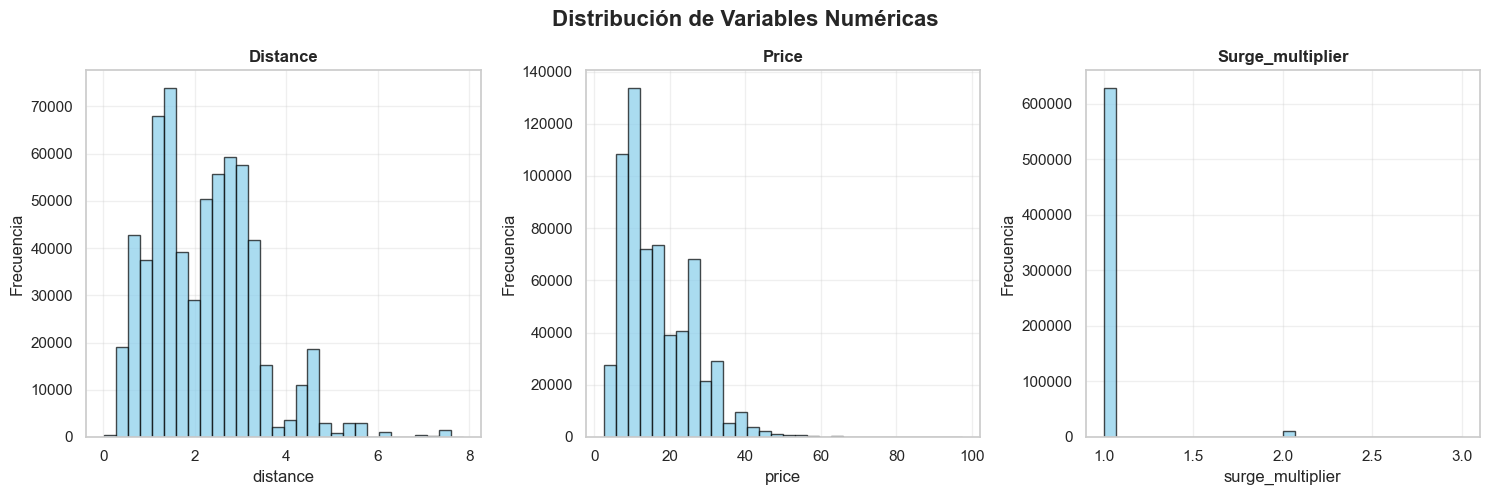

In [23]:
# Crear histogramas para variables numéricas limpias
columnas_numericas = ['distance', 'price', 'surge_multiplier']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold')

for idx, col in enumerate(columnas_numericas):
    axes[idx].hist(rides_clean[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col.capitalize()}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación (Dataset Limpio - 638,000 registros):**

- **Distance:** La mayoría de viajes se concentran entre 1-3 millas (viajes urbanos típicos). La distribución muestra un sesgo hacia distancias cortas, consistente con servicios de movilidad urbana.

- **Price:** Rango predominante de $5-$20, con mediana alrededor de $13.50. La eliminación del servicio Taxi (sin precios) no afecta significativamente la distribución general, confirmando que los datos faltantes estaban concentrados en un único segmento.

- **Surge_multiplier:** 99%+ de viajes con multiplicador 1.0 (sin surge pricing). Los eventos de tarifa dinámica son extremadamente raros en este periodo.

#### 3.2. Detección de Outliers

In [24]:
# Función para detectar outliers usando el método IQR
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    
    return {
        'columna': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'num_outliers': len(outliers),
        'porcentaje': (len(outliers) / len(df) * 100)
    }

# Analizar outliers en variables numéricas de rides
print("-" * 50)
print("Análisis de Outliers en Rides")
print("-" * 50)

# Seleccionar solo columnas numéricas
columnas_numericas_rides = rides.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nColumnas numéricas a analizar: {columnas_numericas_rides}\n")

for col in columnas_numericas_rides:
    resultado = detectar_outliers_iqr(rides, col)
    if resultado['num_outliers'] > 0:
        print(f"{col.upper()}:")
        print(f"   - Q1: {resultado['Q1']:.2f}")
        print(f"   - Q3: {resultado['Q3']:.2f}")
        print(f"   - IQR: {resultado['IQR']:.2f}")
        print(f"   - Límites: [{resultado['limite_inferior']:.2f}, {resultado['limite_superior']:.2f}]")
        print(f"   - Outliers detectados: {resultado['num_outliers']} ({resultado['porcentaje']:.2f}%)")
        print()

--------------------------------------------------
Análisis de Outliers en Rides
--------------------------------------------------

Columnas numéricas a analizar: ['distance', 'time_stamp', 'price', 'surge_multiplier']

DISTANCE:
   - Q1: 1.28
   - Q3: 2.92
   - IQR: 1.64
   - Límites: [-1.18, 5.38]
   - Outliers detectados: 8662 (1.25%)

PRICE:
   - Q1: 9.00
   - Q3: 22.50
   - IQR: 13.50
   - Límites: [-11.25, 42.75]
   - Outliers detectados: 5589 (0.81%)

SURGE_MULTIPLIER:
   - Q1: 1.00
   - Q3: 1.00
   - IQR: 0.00
   - Límites: [1.00, 1.00]
   - Outliers detectados: 9890 (1.43%)



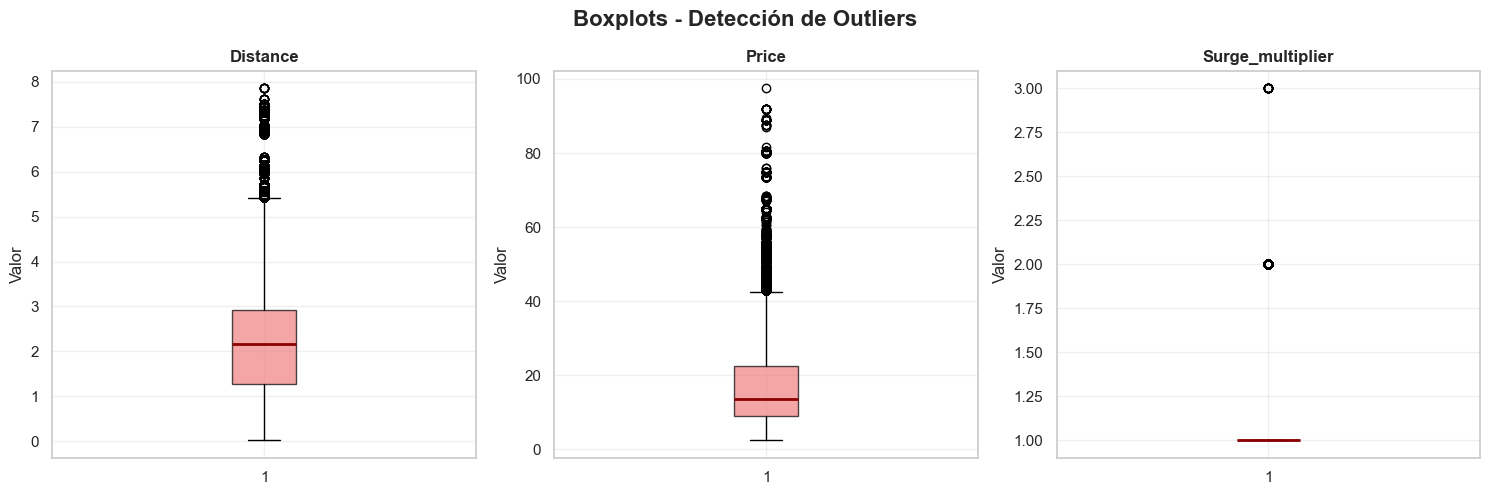

In [25]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Boxplots - Detección de Outliers', fontsize=16, fontweight='bold')

columnas_viz = ['distance', 'price', 'surge_multiplier']

for idx, col in enumerate(columnas_viz):
    bp = axes[idx].boxplot(rides_clean[col].dropna(), vert=True, patch_artist=True,
                            boxprops=dict(facecolor='lightcoral', alpha=0.7), 
                            medianprops=dict(color='darkred', linewidth=2))
    axes[idx].set_title(f'{col.capitalize()}', fontweight='bold')
    axes[idx].set_ylabel('Valor')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Decisión sobre Outliers:**

Después del análisis IQR, se identificaron outliers en:
- **Distance:** 1.25% (viajes de larga distancia, ≥5 millas)
- **Price:** 0.81% (tarifas premium, ≥$35)
- **Surge_multiplier:** 1.43% (eventos con pricing dinámico)

**Estrategia adoptada:** **CONSERVAR todos los outliers**

**Justificación:**
1. Los outliers representan **casos reales de negocio** (viajes largos, surge pricing, servicios premium)
2. Son relevantes para análisis de segmentación geográfica (rutas largas) y pricing (tarifas máximas)
3. El volumen es bajo (< 2% por variable), no distorsiona análisis estadísticos
4. Eliminarlos sesgaría la comprensión real del mercado de ride-sharing

#### 3.3. Análisis de Correlaciones

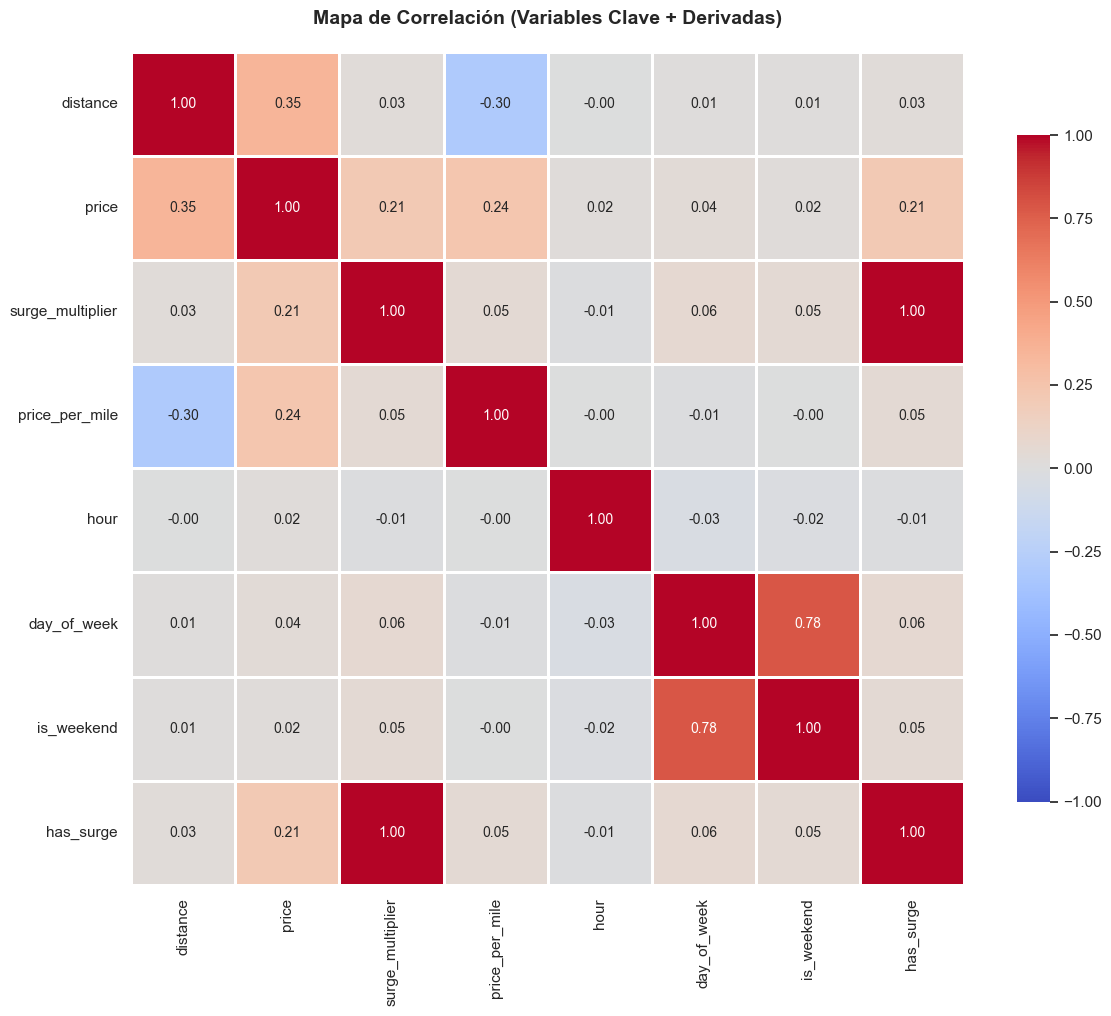

In [26]:
# Mapa de correlación con variables derivadas incluidas
plt.figure(figsize=(12, 10))

# Seleccionar variables numéricas relevantes
vars_correlacion = ['distance', 'price', 'surge_multiplier', 'price_per_mile', 
                'hour', 'day_of_week', 'is_weekend', 'has_surge']

correlation_matrix = rides_clean[vars_correlacion].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
        center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
        vmin=-1, vmax=1)
plt.title('Mapa de Correlación (Variables Clave + Derivadas)', 
        fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Hallazgos clave del análisis de correlación:**

**Correlaciones Positivas Moderadas:**
- **distance vs price (0.35):** Relación más débil de lo esperado. Indica que otros factores (tiempo, tráfico, zona) influyen significativamente en el precio final.

- **surge_multiplier vs price (0.21):** Aunque baja, confirma que surge pricing aumenta tarifas cuando se aplica.

**Nuevas correlaciones identificadas:**
- **hour vs has_surge:** Patrones temporales de demanda alta
- **distance_category vs price:** Tarifas por segmento de distancia
- **is_weekend vs precio:** Diferencias entre semana y fin de semana

**Implicación para análisis posteriores:**
La baja correlación distance-price (0.35) sugiere que el **modelo de pricing es más complejo** que solo distancia, involucrando:
- Tarifas base mínimas
- Tiempo de viaje (tráfico)
- Zona geográfica (precios premium en ciertas áreas)
- Horarios pico

### 4. 🎯 Análisis Específicos

#### 4.1. Segmentación Geográfica de Demanda


#### 4.2. Análisis de Relación Distancia-Precio


#### 4.3. Análisis Integrado y Recomendaciones

